In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ── Column names (NASA CMAPSS dataset format) ─────────────────────────────────
COLS = [
    'Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA',
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
SENSORS = COLS[5:]       # 21 sensor readings (columns 5 – 25)

# ── Maintenance thresholds ────────────────────────────────────────────────────
W           = 30    # "urgent" = true RUL < W cycles at observation cutoff
LEAD_TIME   = W     # honest evaluation: alarm must fire >= LEAD_TIME cycles before cutoff
RUL_CAP     = 125   # regression target cap — engines don't improve past this

# ── Feature engineering parameters ───────────────────────────────────────────
BASELINE_N   = 10   # cycles used to freeze the healthy baseline
TREND_SMOOTH = 10   # rolling-mean window applied before computing the slope
TREND_WINDOW = 20   # cycle gap used to compute the slope (diff over N cycles)

In [3]:
def load_training(filename):
    """Load a CMAPSS training file. Engines run to failure, so we know the true RUL."""
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None).iloc[:, :26]
    df.columns = COLS
    # max_cycle is the engine's total lifetime — legitimate ground truth label
    max_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('max_cycle')
    df = df.join(max_cycle, on='Unit Number')
    df['RUL'] = df['max_cycle'] - df['Time (Cycles)']
    return df

def load_nasa_test(filename, rul_file):
    """Load a CMAPSS test file. Engines are cut before failure; true RUL is in the ground-truth file."""
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None).iloc[:, :26]
    df.columns = COLS
    rul_gt = pd.read_csv(f'../Data/{rul_file}', header=None, names=['true_rul'])
    rul_gt['Unit Number'] = rul_gt.index + 1
    last_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('last_cycle')
    df = df.join(last_cycle, on='Unit Number')
    df = df.join(rul_gt.set_index('Unit Number')['true_rul'], on='Unit Number')
    # Reconstruct per-cycle RUL from ground-truth: at the cutoff, RUL = true_rul
    df['RUL'] = (df['last_cycle'] + df['true_rul']) - df['Time (Cycles)']
    return df

# Offset unit numbers so engines from FD001–FD004 never share an ID
offset = 0; train_parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_training(f'train_{fd}.txt')
    d['Unit Number'] += offset; d['dataset'] = fd
    offset = d['Unit Number'].max(); train_parts.append(d)
df_all = pd.concat(train_parts, ignore_index=True)

offset = 0; nasa_parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_nasa_test(f'test_{fd}.txt', f'RUL_{fd}.txt')
    d['Unit Number'] += offset; d['dataset'] = fd
    offset = d['Unit Number'].max(); nasa_parts.append(d)
nasa_raw = pd.concat(nasa_parts, ignore_index=True)

print(f"Training : {df_all['Unit Number'].nunique():>4} engines | {len(df_all):>7,} rows")
print(f"NASA test: {nasa_raw['Unit Number'].nunique():>4} engines | {len(nasa_raw):>7,} rows")

Training :  709 engines | 160,359 rows
NASA test:  707 engines | 104,897 rows


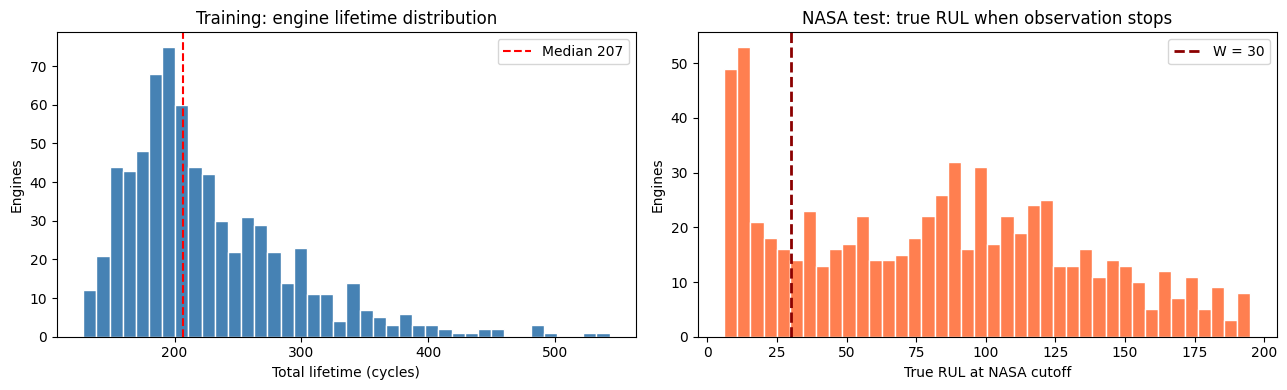

Urgent engines in NASA test by warning window W:
  W =  15:   91/707 = 12.9% urgent
  W =  20:  119/707 = 16.8% urgent
  W =  25:  141/707 = 19.9% urgent
  W =  30:  157/707 = 22.2% urgent
  W =  50:  225/707 = 31.8% urgent
  W =  75:  315/707 = 44.6% urgent


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lifetimes = df_all.groupby('Unit Number')['max_cycle'].first()
axes[0].hist(lifetimes, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(lifetimes.median(), color='red', ls='--', lw=1.5, label=f'Median {int(lifetimes.median())}')
axes[0].set(xlabel='Total lifetime (cycles)', ylabel='Engines',
            title='Training: engine lifetime distribution'); axes[0].legend()

nasa_rul = nasa_raw.groupby('Unit Number')['true_rul'].first()
axes[1].hist(nasa_rul, bins=40, color='coral', edgecolor='white')
axes[1].axvline(W, color='darkred', ls='--', lw=2, label=f'W = {W}')
axes[1].set(xlabel='True RUL at NASA cutoff', ylabel='Engines',
            title='NASA test: true RUL when observation stops'); axes[1].legend()
plt.tight_layout(); plt.show()

print("Urgent engines in NASA test by warning window W:")
for w in [15, 20, 25, 30, 50, 75]:
    n = (nasa_rul < w).sum()
    print(f"  W = {w:>3}: {n:>4}/{len(nasa_rul)} = {n/len(nasa_rul):.1%} urgent")

In [5]:
print(f"Raw sensor columns ({len(SENSORS)}):")
print("  " + ", ".join(SENSORS))

# Quick sanity check: verify none of SENSORS is derived from future data
assert 'RUL' not in SENSORS and 'max_cycle' not in SENSORS, "Leakage detected!"
print("\nLeakage check: SENSORS contains no RUL or max_cycle. ✓")

Raw sensor columns (21):
  T2, T24, T30, T50, P2, P15, P30, Nf, Nc, epr, Ps30, phi, NRf, NRc, BPR, farB, htBleed, Nf_dmd, PCNfR_dmd, W31, W32

Leakage check: SENSORS contains no RUL or max_cycle. ✓


### Feature 2 — Baseline deviation (`_dev`)

**What**: For each sensor, how far is the current reading from the engine's own *early-life* healthy state?

**How**:
1. Compute the expanding (cumulative) mean of the sensor over the first `BASELINE_N` cycles — this is the "healthy baseline".
2. Freeze that mean at cycle `BASELINE_N` so it never changes again.
3. `dev[t] = sensor[t] − baseline`

A sensor reading of 450 means nothing in isolation. The same sensor starting at 460 and drifting to 450 signals something different from one that started at 440 and drifted to 450. The `_dev` feature captures this personalised shift.

**Leakage check**: the expanding mean only uses cycles 1 … t; the baseline is frozen at the first 10 cycles, using no future data. ✓

In [6]:
DEV_COLS = [f'{s}_dev' for s in SENSORS]

parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    n   = len(eng)
    cumean = eng[SENSORS].expanding(min_periods=1).mean()
    frozen = cumean.iloc[min(BASELINE_N - 1, n - 1)]   # freeze at cycle BASELINE_N
    new = {}
    for s in SENSORS:
        baseline = np.where(np.arange(n) < BASELINE_N, cumean[s].values, frozen[s])
        new[f'{s}_dev'] = eng[s].values - baseline
    parts.append(pd.DataFrame(new, index=eng.index))
feat_dev_train = pd.concat(parts)
for col in DEV_COLS: df_all[col] = feat_dev_train[col]

parts = []
for unit, eng in nasa_raw.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    n   = len(eng)
    cumean = eng[SENSORS].expanding(min_periods=1).mean()
    frozen = cumean.iloc[min(BASELINE_N - 1, n - 1)]
    new = {}
    for s in SENSORS:
        baseline = np.where(np.arange(n) < BASELINE_N, cumean[s].values, frozen[s])
        new[f'{s}_dev'] = eng[s].values - baseline
    parts.append(pd.DataFrame(new, index=eng.index))
feat_dev_nasa = pd.concat(parts)
for col in DEV_COLS: nasa_raw[col] = feat_dev_nasa[col]

print(f"Added {len(DEV_COLS)} deviation features (e.g. T30_dev, Ps30_dev)")
print(f"Example — T30_dev stats (training):  mean={df_all['T30_dev'].mean():.3f}, std={df_all['T30_dev'].std():.3f}")

Added 21 deviation features (e.g. T30_dev, Ps30_dev)
Example — T30_dev stats (training):  mean=0.664, std=93.763


### Feature 3 — Local trend (`_trend`)

**What**: The rate of change of a sensor over the last `TREND_WINDOW` cycles — how fast is it moving right now?

**How**:
1. Smooth the raw sensor with a rolling mean (`TREND_SMOOTH` cycles) to reduce noise.
2. Take the difference over `TREND_WINDOW` cycles and divide by window size.
3. `trend[t] = (smooth[t] − smooth[t − 20]) / 20`

The `_dev` feature tells you *how far* a sensor has drifted from baseline; the `_trend` feature tells you *how fast it is moving*. An engine might still be within normal bounds but accelerating rapidly towards failure.

**Leakage check**: rolling mean and diff only look backwards. `fillna(0)` handles the initial window where there's not enough history — it's a neutral value, not imputed from the future. ✓

In [7]:
TREND_COLS = [f'{s}_trend' for s in SENSORS]

parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {}
    for s in SENSORS:
        sm = eng[s].rolling(TREND_SMOOTH, min_periods=1).mean()
        new[f'{s}_trend'] = sm.diff(TREND_WINDOW).fillna(0).values / TREND_WINDOW
    parts.append(pd.DataFrame(new, index=eng.index))
feat_trend_train = pd.concat(parts)
for col in TREND_COLS: df_all[col] = feat_trend_train[col]

parts = []
for unit, eng in nasa_raw.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {}
    for s in SENSORS:
        sm = eng[s].rolling(TREND_SMOOTH, min_periods=1).mean()
        new[f'{s}_trend'] = sm.diff(TREND_WINDOW).fillna(0).values / TREND_WINDOW
    parts.append(pd.DataFrame(new, index=eng.index))
feat_trend_nasa = pd.concat(parts)
for col in TREND_COLS: nasa_raw[col] = feat_trend_nasa[col]

print(f"Added {len(TREND_COLS)} trend features (e.g. T50_trend, NRc_trend)")

Added 21 trend features (e.g. T50_trend, NRc_trend)


### Feature 4 — Global history slope (`_hslope`)

**What**: The average degradation *rate* over the engine's entire observed life — from cycle 1 to the current cycle.

**How**:
```
hslope[t] = (expanding_mean[t] − sensor[cycle_1]) / t
```

**Why this is different from `_dev` and `_trend`**:
- `_dev` tells you total drift from baseline (absolute offset)
- `_trend` tells you how fast things are changing *right now* (local velocity over last 20 cycles)
- `_hslope` tells you the *average drift rate per cycle since the engine was new* (global degradation rate)

An engine with a steady long-term slope is on a predictable trajectory. An engine with the same current `_dev` but fewer elapsed cycles has degraded much faster — that's higher `_hslope` and a stronger danger signal.

**Leakage check**: `expanding_mean` at cycle t uses only cycles 1 … t; `sensor[cycle_1]` is the observed first reading (never future data). ✓

In [8]:
HSLOPE_COLS = [f'{s}_hslope' for s in SENSORS]

parts = []
for unit, eng in df_all.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {}
    for s in SENSORS:
        hist_mean = eng[s].expanding(min_periods=1).mean()
        new[f'{s}_hslope'] = (
            (hist_mean.values - eng[s].iloc[0])
            / np.maximum(eng['Time (Cycles)'].values, 1)
        )
    parts.append(pd.DataFrame(new, index=eng.index))
feat_hslope_train = pd.concat(parts)
for col in HSLOPE_COLS: df_all[col] = feat_hslope_train[col]

parts = []
for unit, eng in nasa_raw.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').copy()
    new = {}
    for s in SENSORS:
        hist_mean = eng[s].expanding(min_periods=1).mean()
        new[f'{s}_hslope'] = (
            (hist_mean.values - eng[s].iloc[0])
            / np.maximum(eng['Time (Cycles)'].values, 1)
        )
    parts.append(pd.DataFrame(new, index=eng.index))
feat_hslope_nasa = pd.concat(parts)
for col in HSLOPE_COLS: nasa_raw[col] = feat_hslope_nasa[col]

print(f"Added {len(HSLOPE_COLS)} history-slope features")

Added 21 history-slope features


### Feature 5 — Sensor ratios

**What**: Ratios of sensor pairs that have physical meaning in a gas-turbine thermodynamic cycle.

**Why**: Raw sensor values shift with operating condition (altitude, Mach, throttle). Ratios between related sensors are more stable across conditions — they capture *relative* efficiency losses rather than absolute readings.

### Sensors used in ratios

| Sensor | Type | Location in the engine |
|---|---|---|
| T24 | Total temperature | Low-pressure compressor (LPC) outlet — air entering HPC |
| T30 | Total temperature | High-pressure compressor (HPC) outlet — air entering combustor |
| T50 | Total temperature | Low-pressure turbine (LPT) outlet — exhaust leaving core |
| P2  | Total pressure    | Fan inlet — ambient + ram pressure entering the engine |
| P15 | Total pressure    | Bypass duct — cold air stream that bypasses the core |
| P30 | Total pressure    | High-pressure compressor (HPC) outlet — peak pressure in the cycle |
| NRf | Corrected speed   | Fan — large front rotor, drives the bypass stream |
| NRc | Corrected speed   | Core (high-pressure spool) — compressor + turbine on the same shaft |

### Ratios and their meaning

| Ratio | Physical meaning |
|---|---|
| T30 / T24 | HPC temperature ratio — rises as compressor efficiency drops (more work to achieve the same pressure) |
| T50 / T30 | Turbine temperature ratio — rises as turbine degrades (less energy extracted per unit of hot gas) |
| P30 / P2  | Overall pressure ratio — falls as compressor wear reduces its ability to pressurise air |
| P30 / P15 | HPC-to-bypass pressure ratio — captures the balance between core and bypass streams |
| NRf / NRc | Fan-to-core speed ratio — imbalance between the two spools signals mechanical wear |

**Leakage check**: ratios use only the current cycle's readings. ✓

In [9]:
RATIO_PAIRS = [
    ('T30', 'T24'), ('T50', 'T30'),
    ('P30', 'P2'),  ('P30', 'P15'),
    ('NRf', 'NRc'),
]
RATIO_COLS = [f'{n}_over_{d}' for n, d in RATIO_PAIRS]

for df in [df_all, nasa_raw]:
    for num, den in RATIO_PAIRS:
        df[f'{num}_over_{den}'] = df[num] / df[den].clip(lower=1e-6)

print(f"Added {len(RATIO_COLS)} ratio features:")
for col in RATIO_COLS:
    print(f"  {col}")

Added 5 ratio features:
  T30_over_T24
  T50_over_T30
  P30_over_P2
  P30_over_P15
  NRf_over_NRc


## Experimental Features

This is the cell to edit when testing new feature ideas.

**Workflow:**
1. Add your feature code to the cell below — it must add columns to **both** `df_all` and `nasa_raw`
2. Append the new column names to `EXPERIMENTAL_COLS`
3. Re-run this cell and everything from **"Assemble feature columns"** onwards
4. Compare the before/after metrics in the evaluation cells

**Leakage rules (same as above)**: only backward-looking operations, no RUL, no max_cycle.

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENTAL FEATURES
# Add new features here. Must add columns to BOTH df_all AND nasa_raw.
# Append new column names to EXPERIMENTAL_COLS.
# Re-run this cell, then re-run from "Assemble feature columns" onwards.
# ══════════════════════════════════════════════════════════════════════════════

EXPERIMENTAL_COLS = []

# ── Example 1: Lag features (sensor reading N cycles ago) ─────────────────────
# Gives the model a "memory" of recent history without relying on aggregates.
#
# LAG_PERIODS = [1, 5, 10]
# LAG_COLS = [f'{s}_lag{lag}' for s in SENSORS for lag in LAG_PERIODS]
# for df in [df_all, nasa_raw]:
#     parts = []
#     for unit, eng in df.groupby('Unit Number'):
#         eng = eng.sort_values('Time (Cycles)').copy()
#         new = {}
#         for lag in LAG_PERIODS:
#             for s in SENSORS:
#                 new[f'{s}_lag{lag}'] = eng[s].shift(lag).fillna(eng[s].iloc[0]).values
#         parts.append(pd.DataFrame(new, index=eng.index))
#     feat = pd.concat(parts)
#     for col in feat.columns: df[col] = feat[col]
# EXPERIMENTAL_COLS += LAG_COLS

# ── Example 2: Rolling standard deviation (noise / instability) ───────────────
# High variance in a previously stable sensor may signal early deterioration.
#
# NOISE_WIN = 20
# NOISE_COLS = [f'{s}_noise' for s in SENSORS]
# for df in [df_all, nasa_raw]:
#     parts = []
#     for unit, eng in df.groupby('Unit Number'):
#         eng = eng.sort_values('Time (Cycles)').copy()
#         new = {f'{s}_noise': eng[s].rolling(NOISE_WIN, min_periods=2).std().fillna(0).values
#                for s in SENSORS}
#         parts.append(pd.DataFrame(new, index=eng.index))
#     feat = pd.concat(parts)
#     for col in feat.columns: df[col] = feat[col]
# EXPERIMENTAL_COLS += NOISE_COLS

# ── Add your own features below ───────────────────────────────────────────────

print(f"Experimental features active: {len(EXPERIMENTAL_COLS)}")
if EXPERIMENTAL_COLS:
    print("  " + ", ".join(EXPERIMENTAL_COLS[:8]) + ("  ..." if len(EXPERIMENTAL_COLS) > 8 else ""))
else:
    print("  (none — uncomment an example or add your own)")

Experimental features active: 0
  (none — uncomment an example or add your own)


In [11]:
# Base feature set (always included)
BASE_FEATURE_COLS = (
    SENSORS
    + DEV_COLS
    + TREND_COLS
    + HSLOPE_COLS
    + RATIO_COLS
    + ['Time (Cycles)']
)

# Final feature set (base + whatever is in EXPERIMENTAL_COLS)
FEATURE_COLS = BASE_FEATURE_COLS + EXPERIMENTAL_COLS

print(f"Feature breakdown:")
print(f"  Raw sensors     : {len(SENSORS)}")
print(f"  Baseline dev    : {len(DEV_COLS)}")
print(f"  Local trend     : {len(TREND_COLS)}")
print(f"  History slope   : {len(HSLOPE_COLS)}")
print(f"  Ratios          : {len(RATIO_COLS)}")
print(f"  Time (Cycles)   : 1")
print(f"  Experimental    : {len(EXPERIMENTAL_COLS)}")
print(f"  ─────────────────────")
print(f"  TOTAL           : {len(FEATURE_COLS)}")

# Verify no NaNs in either dataset
assert not df_all[FEATURE_COLS].isnull().any().any(),  "NaN in training features!"
assert not nasa_raw[FEATURE_COLS].isnull().any().any(), "NaN in NASA features!"
print("\nNaN check: clean. ✓")

Feature breakdown:
  Raw sensors     : 21
  Baseline dev    : 21
  Local trend     : 21
  History slope   : 21
  Ratios          : 5
  Time (Cycles)   : 1
  Experimental    : 0
  ─────────────────────
  TOTAL           : 90

NaN check: clean. ✓


In [12]:
# Split by engine (not by row) so no engine appears in both train and test
engines = df_all[['Unit Number', 'dataset']].drop_duplicates()
train_engines, test_engines = train_test_split(
    engines, test_size=0.2, random_state=42, stratify=engines['dataset']
)
train_df = df_all[df_all['Unit Number'].isin(train_engines['Unit Number'])].copy()
test_df  = df_all[df_all['Unit Number'].isin(test_engines['Unit Number'])].copy()

y_train_cls = (train_df['RUL'] < W).astype(int)
y_test_cls  = (test_df['RUL']  < W).astype(int)
y_train_reg = train_df['RUL'].clip(upper=RUL_CAP).values
y_test_reg  = test_df['RUL'].clip(upper=RUL_CAP).values

pos_rate = y_train_cls.mean()
print(f"Train : {train_df['Unit Number'].nunique()} engines | {len(train_df):,} rows")
print(f"Test  : {test_df['Unit Number'].nunique()} engines | {len(test_df):,} rows")
print(f"Class balance — urgent (RUL<{W}): {pos_rate:.1%}  safe: {1-pos_rate:.1%}")
print(f"scale_pos_weight = {(1-pos_rate)/pos_rate:.1f}  (upweights minority urgent class)")


def evaluate_on_nasa(predict_fn, nasa_df, feature_cols, w=W, lead_time=LEAD_TIME):
    """
    Evaluate a binary prediction function on the NASA hold-out test set.

    Honest criterion: alarm must fire >= lead_time cycles before ACTUAL FAILURE.
      cycles_before_failure = (last_observed_cycle - first_alarm_cycle) + true_rul

    Three outcomes for urgent engines (true RUL < w at cutoff):
      caught_honest — alarm fired >= lead_time cycles before actual failure
      caught_late   — alarm fired, but < lead_time cycles before actual failure
                      (cycles_before_failure is always < lead_time for these)
      never_caught  — alarm never fired; engine would break down undetected
    """
    nasa_c = nasa_df.copy()
    nasa_c['pred'] = predict_fn(nasa_c[feature_cols])

    results = []
    for unit, eng in nasa_c.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)
        true_rul   = float(eng['true_rul'].iloc[0])
        last_cycle = eng['Time (Cycles)'].max()
        is_urgent  = true_rul < w

        ever_fired = (eng['pred'] == 1).any()

        if ever_fired:
            first_alarm_cycle     = eng.loc[eng['pred'] == 1, 'Time (Cycles)'].iloc[0]
            cycles_before_failure = (last_cycle - first_alarm_cycle) + true_rul
            fired_in_time         = cycles_before_failure >= lead_time
        else:
            first_alarm_cycle     = None
            cycles_before_failure = None
            fired_in_time         = False

        results.append({
            'unit': unit, 'true_rul': true_rul, 'is_urgent': is_urgent,
            'fired_in_time': fired_in_time, 'ever_fired': ever_fired,
            'cycles_before_failure': cycles_before_failure,
        })

    df_r   = pd.DataFrame(results)
    urgent = df_r[df_r['is_urgent']]
    safe   = df_r[~df_r['is_urgent']]

    caught_honest = int(urgent['fired_in_time'].sum())
    caught_late   = int((urgent['ever_fired'] & ~urgent['fired_in_time']).sum())
    never_caught  = int((~urgent['ever_fired']).sum())

    late_mask   = urgent['ever_fired'] & ~urgent['fired_in_time']
    honest_mask = urgent['fired_in_time']
    late_cbf    = urgent.loc[late_mask,   'cycles_before_failure'].dropna().values
    honest_cbf  = urgent.loc[honest_mask, 'cycles_before_failure'].dropna().values

    def rate(col, subset): return subset[col].sum() / len(subset) if len(subset) else 0.0

    return {
        'n_urgent'      : len(urgent),
        'recall_honest' : rate('fired_in_time', urgent),
        'caught_honest' : caught_honest,
        'caught_late'   : caught_late,
        'never_caught'  : never_caught,
        'recall_lenient': rate('ever_fired', urgent),
        'caught_lenient': int(urgent['ever_fired'].sum()),
        'false_alarm'   : rate('ever_fired', safe),
        'late_cbf'      : late_cbf,    # cycles before failure for caught-late — always < lead_time
        'honest_cbf'    : honest_cbf,  # cycles before failure for caught-honest — always >= lead_time
        'details'       : df_r,
    }

Train : 567 engines | 128,042 rows
Test  : 142 engines | 32,317 rows
Class balance — urgent (RUL<30): 13.3%  safe: 86.7%
scale_pos_weight = 6.5  (upweights minority urgent class)


## Binary Classifier — "Does this engine need service within W cycles?"

### Model design choices
- **Target**: `(RUL < W)` — a 1/0 label per cycle-row
- **`scale_pos_weight`**: corrects for class imbalance (~13% of rows are urgent). Without this, the model ignores the minority class.
- **`eval_set` + early stopping**: monitors hold-out loss to stop when generalisation stops improving. The eval set here is from the *training files* (engines that ran to failure), separate from the NASA hold-out used in final evaluation.
- We optimise for recall (catching urgent engines) at the cost of more false alarms.

In [13]:
spw = (1 - pos_rate) / pos_rate   # scale_pos_weight

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)
clf.fit(
    train_df[FEATURE_COLS], y_train_cls,
    eval_set=[(test_df[FEATURE_COLS], y_test_cls)],
    verbose=False,
)
print(f"Best iteration: {clf.best_iteration}  |  best logloss: {clf.best_score:.4f}")

Best iteration: 299  |  best logloss: 0.1010


                 precision    recall  f1-score   support

  Safe (RUL≥30)       1.00      0.96      0.98     28057
Urgent (RUL<30)       0.77      0.97      0.86      4260

       accuracy                           0.96     32317
      macro avg       0.88      0.96      0.92     32317
   weighted avg       0.97      0.96      0.96     32317



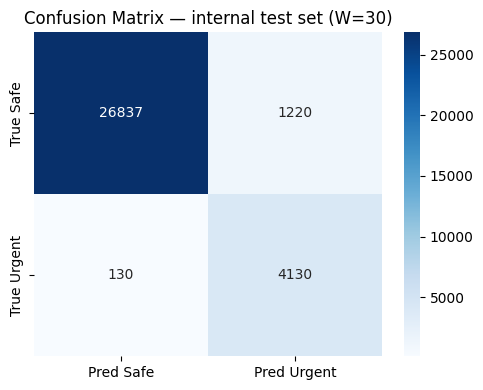

In [14]:
y_pred_cls = clf.predict(test_df[FEATURE_COLS])
print(classification_report(y_test_cls, y_pred_cls, target_names=[f'Safe (RUL≥{W})', f'Urgent (RUL<{W})']))

cm = confusion_matrix(y_test_cls, y_pred_cls)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Safe', 'Pred Urgent'],
            yticklabels=['True Safe', 'True Urgent'], ax=ax)
ax.set_title(f'Confusion Matrix — internal test set (W={W})')
plt.tight_layout(); plt.show()

=== Classifier — NASA hold-out evaluation (W=30) ===
    LEAD_TIME = 30 cycles  (alarm must fire this far before the cutoff)

  Urgent engines (true RUL < 30): 157

  Outcome for urgent engines:
    Caught with ≥30 cycles lead time : 125  (79.6%)  ← honest recall
    Caught but too late (< 30 cycles) :  30  (19.1%)  ← alarm fired, not enough time
    Never flagged — breakdown undetected :   2  (1.3%)  ← most dangerous

  Lenient recall (ever fired, any timing): 155/157 = 98.7%
  False alarm rate (safe engines flagged): 11.6%

  Honest vs lenient gap: 19.1%
  — 30 engines were 'caught' only at the last moment, which the
    lenient metric counts as a success but the honest metric does not.


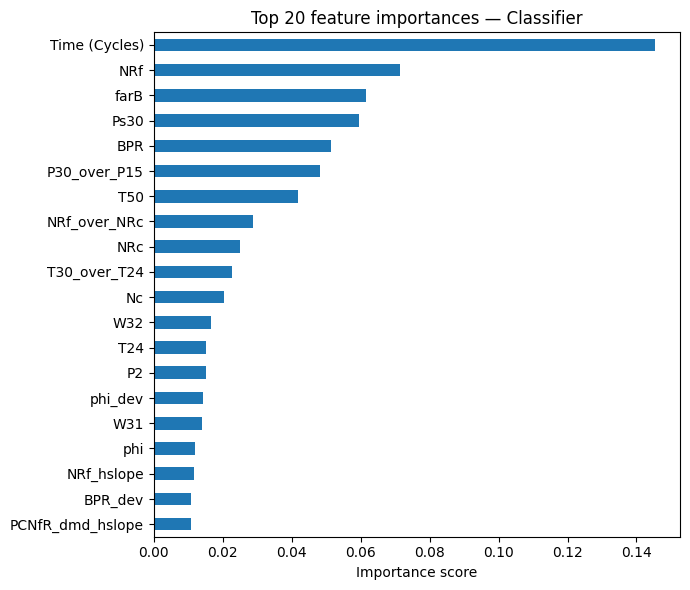

In [15]:
print(f"=== Classifier — NASA hold-out evaluation (W={W}) ===")
print(f"    LEAD_TIME = {LEAD_TIME} cycles  (alarm must fire this far before the cutoff)\n")

r = evaluate_on_nasa(
    predict_fn=lambda X: clf.predict(X),
    nasa_df=nasa_raw, feature_cols=FEATURE_COLS,
)

print(f"  Urgent engines (true RUL < {W}): {r['n_urgent']}")
print()
print(f"  Outcome for urgent engines:")
print(f"    Caught with ≥{LEAD_TIME} cycles lead time : {r['caught_honest']:>3}  ({r['recall_honest']:.1%})  ← honest recall")
print(f"    Caught but too late (< {LEAD_TIME} cycles) : {r['caught_late']:>3}  ({r['caught_late']/r['n_urgent']:.1%})  ← alarm fired, not enough time")
print(f"    Never flagged — breakdown undetected : {r['never_caught']:>3}  ({r['never_caught']/r['n_urgent']:.1%})  ← most dangerous")
print()
print(f"  Lenient recall (ever fired, any timing): {r['caught_lenient']}/{r['n_urgent']} = {r['recall_lenient']:.1%}")
print(f"  False alarm rate (safe engines flagged): {r['false_alarm']:.1%}")
print()
print(f"  Honest vs lenient gap: {r['recall_lenient']-r['recall_honest']:.1%}")
print(f"  — {r['caught_late']} engines were 'caught' only at the last moment, which the")
print(f"    lenient metric counts as a success but the honest metric does not.")

# Feature importance
feat_imp = pd.Series(clf.feature_importances_, index=FEATURE_COLS).nlargest(20)
fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax)
ax.set(title='Top 20 feature importances — Classifier', xlabel='Importance score')
plt.tight_layout(); plt.show()

In [16]:
print("=== Classifier — W sweep (honest metric = W cycles before actual failure) ===\n")
sweep_rows = []
for w in [15, 20, 25, 30, 40, 50, 75]:
    yt = (train_df['RUL'] < w).astype(int)
    p  = yt.mean()
    m  = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(1-p)/p,
        random_state=42, n_jobs=-1,
    )
    m.fit(train_df[FEATURE_COLS], yt, verbose=False)
    r = evaluate_on_nasa(
        predict_fn=lambda X, m=m: m.predict(X),
        nasa_df=nasa_raw, feature_cols=FEATURE_COLS,
        w=w, lead_time=w,
    )
    late_avg = f"{r['late_cbf'].mean():.1f}" if len(r['late_cbf']) > 0 else "—"
    sweep_rows.append({
        'W': w, 'Urgent': r['n_urgent'],
        'Caught (honest)': r['caught_honest'],
        'Caught late': r['caught_late'],
        'Never caught': r['never_caught'],
        'Honest recall': f"{r['recall_honest']:.1%}",
        'Late avg cbf': late_avg,
        'False alarm': f"{r['false_alarm']:.1%}",
    })

print(pd.DataFrame(sweep_rows).to_string(index=False))
print()
print("Column guide:")
print("  Caught (honest) — alarm fired >= W cycles before actual failure; actionable")
print("  Caught late     — alarm fired, but < W cycles before actual failure; too late")
print("  Never caught    — alarm never fired; breakdown without warning")
print("  Late avg cbf    — avg cycles before failure when alarm fired (for caught-late; always < W)")

=== Classifier — W sweep (honest metric = W cycles before actual failure) ===

 W  Urgent  Caught (honest)  Caught late  Never caught Honest recall Late avg cbf False alarm
15      91               74           17             0         81.3%         12.5        9.4%
20     119              104           14             1         87.4%         17.1       10.4%
25     141              116           22             3         82.3%         21.4       12.2%
30     157              125           30             2         79.6%         25.1       12.7%
40     194              154           38             2         79.4%         33.7       16.4%
50     225              165           57             3         73.3%         41.8       21.2%
75     315              202           99            14         64.1%         60.9       30.6%

Column guide:
  Caught (honest) — alarm fired >= W cycles before actual failure; actionable
  Caught late     — alarm fired, but < W cycles before actual failure; too l

Building W sweep data for plots...
  W= 15: honest=81.3%  late= 17  never= 0
  W= 20: honest=87.4%  late= 14  never= 1
  W= 25: honest=82.3%  late= 22  never= 3
  W= 30: honest=79.6%  late= 30  never= 2
  W= 40: honest=79.4%  late= 38  never= 2
  W= 50: honest=73.3%  late= 57  never= 3
  W= 75: honest=64.1%  late= 99  never=14


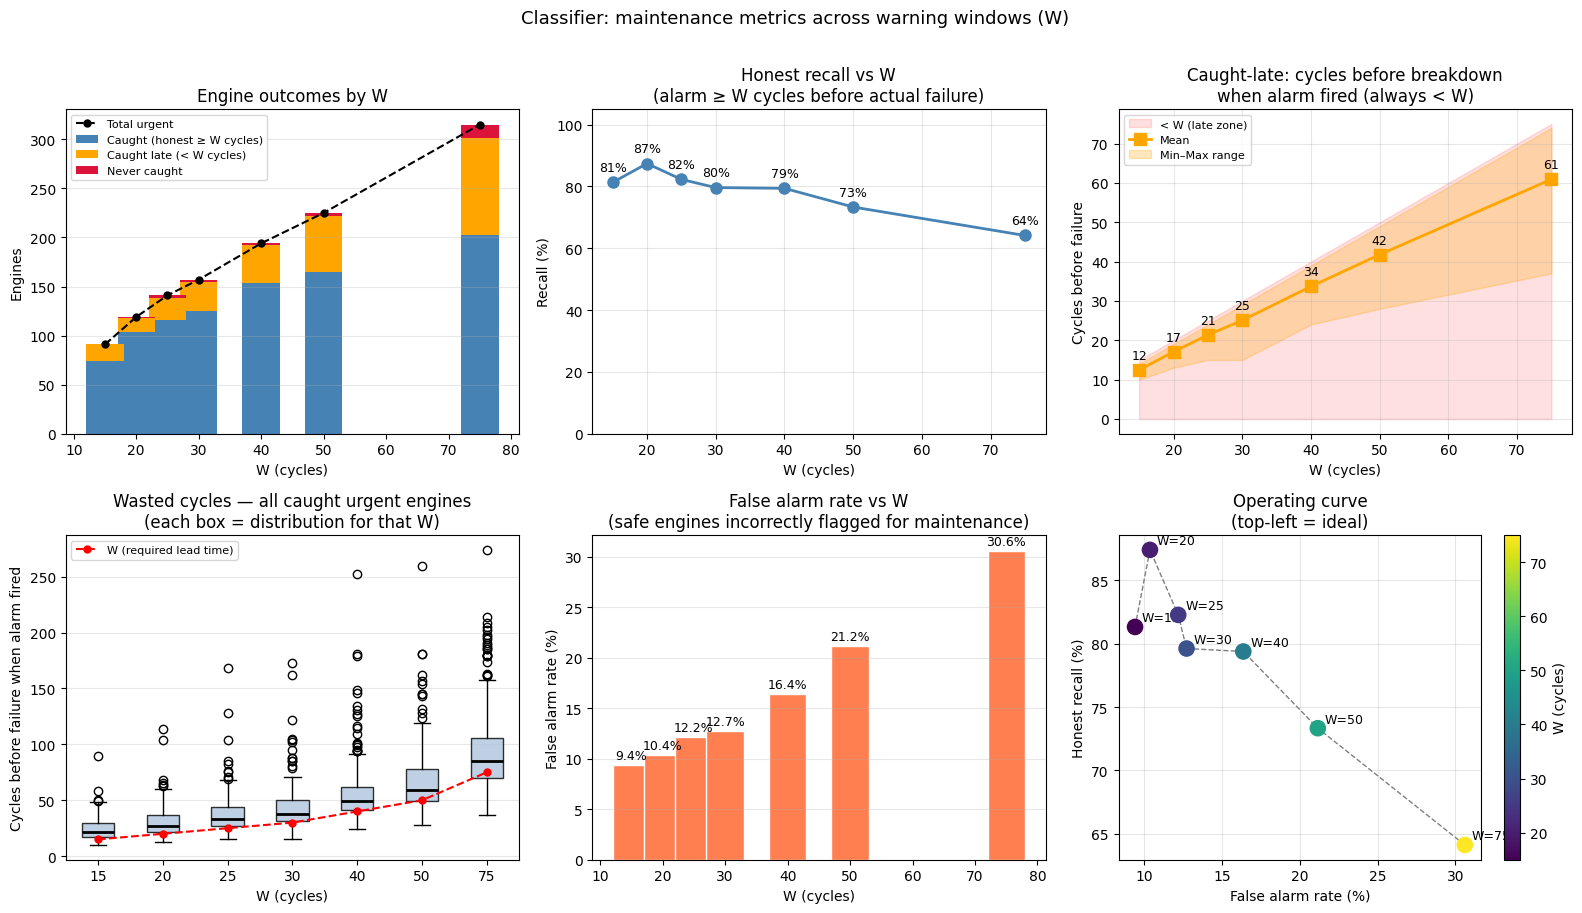

In [17]:
# Re-run the W sweep collecting cbf arrays needed for the plots
print("Building W sweep data for plots...")
ws      = [15, 20, 25, 30, 40, 50, 75]
sw_ch   = []   # caught_honest count
sw_cl   = []   # caught_late count
sw_nc   = []   # never_caught count
sw_urg  = []   # total urgent
sw_rec  = []   # honest recall %
sw_fa   = []   # false alarm %
sw_lcbf = []   # late_cbf arrays (cycles before failure for caught-late engines)
sw_hcbf = []   # honest_cbf arrays

for w in ws:
    yt = (train_df['RUL'] < w).astype(int)
    p  = yt.mean()
    m  = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(1-p)/p, random_state=42, n_jobs=-1,
    )
    m.fit(train_df[FEATURE_COLS], yt, verbose=False)
    r = evaluate_on_nasa(lambda X, m=m: m.predict(X), nasa_raw, FEATURE_COLS, w=w, lead_time=w)
    sw_ch.append(r['caught_honest']);  sw_cl.append(r['caught_late'])
    sw_nc.append(r['never_caught']);   sw_urg.append(r['n_urgent'])
    sw_rec.append(r['recall_honest'] * 100)
    sw_fa.append(r['false_alarm'] * 100)
    sw_lcbf.append(r['late_cbf']);     sw_hcbf.append(r['honest_cbf'])
    print(f"  W={w:>3}: honest={r['recall_honest']:.1%}  late={r['caught_late']:>3}  never={r['never_caught']:>2}")

# ─── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Classifier: maintenance metrics across warning windows (W)', fontsize=13, y=1.01)

bot_late  = np.array(sw_ch)
bot_never = bot_late + np.array(sw_cl)

# 1. Stacked bar: engine outcomes
ax = axes[0, 0]
ax.bar(ws, sw_ch,  color='steelblue', width=6, label='Caught (honest ≥ W cycles)')
ax.bar(ws, sw_cl,  color='orange',    width=6, bottom=sw_ch,         label='Caught late (< W cycles)')
ax.bar(ws, sw_nc,  color='crimson',   width=6, bottom=list(bot_never), label='Never caught')
ax.plot(ws, sw_urg, 'k--o', ms=5, lw=1.5, label='Total urgent')
ax.set(xlabel='W (cycles)', ylabel='Engines', title='Engine outcomes by W')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# 2. Honest recall
ax = axes[0, 1]
ax.plot(ws, sw_rec, 'o-', color='steelblue', lw=2, ms=8)
for x, y in zip(ws, sw_rec):
    ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set(xlabel='W (cycles)', ylabel='Recall (%)',
       title='Honest recall vs W\n(alarm ≥ W cycles before actual failure)')
ax.set_ylim(0, 105); ax.grid(True, alpha=0.3)

# 3. Caught-late: avg cycles before failure
late_means = [v.mean() if len(v) > 0 else 0 for v in sw_lcbf]
late_mins  = [v.min()  if len(v) > 0 else 0 for v in sw_lcbf]
late_maxs  = [v.max()  if len(v) > 0 else 0 for v in sw_lcbf]
ax = axes[0, 2]
ax.fill_between(ws, 0, ws, alpha=0.12, color='red', label='< W (late zone)')
ax.plot(ws, late_means, 's-', color='orange', lw=2, ms=8, label='Mean')
ax.fill_between(ws, late_mins, late_maxs, alpha=0.25, color='orange', label='Min–Max range')
for x, y in zip(ws, late_means):
    ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set(xlabel='W (cycles)', ylabel='Cycles before failure',
       title='Caught-late: cycles before breakdown\nwhen alarm fired (always < W)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4. Wasted cycles box plots (all caught = honest + late combined)
ax = axes[1, 0]
all_cbf = [np.concatenate([h, l]) if len(h)+len(l) > 0 else np.array([0])
           for h, l in zip(sw_hcbf, sw_lcbf)]
bp = ax.boxplot(all_cbf, positions=range(len(ws)), widths=0.5, patch_artist=True,
                medianprops=dict(color='black', lw=2),
                boxprops=dict(facecolor='lightsteelblue', alpha=0.8))
ax.plot(range(len(ws)), ws, 'r--o', ms=5, lw=1.5, label='W (required lead time)')
ax.set_xticks(range(len(ws))); ax.set_xticklabels(ws)
ax.set(xlabel='W (cycles)', ylabel='Cycles before failure when alarm fired',
       title='Wasted cycles — all caught urgent engines\n(each box = distribution for that W)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# 5. False alarm rate
ax = axes[1, 1]
bars = ax.bar(ws, sw_fa, color='coral', width=6, edgecolor='white')
for bar, y in zip(bars, sw_fa):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{y:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set(xlabel='W (cycles)', ylabel='False alarm rate (%)',
       title='False alarm rate vs W\n(safe engines incorrectly flagged for maintenance)')
ax.grid(True, alpha=0.3, axis='y')

# 6. Operating curve: recall vs false alarm
ax = axes[1, 2]
sc = ax.scatter(sw_fa, sw_rec, c=ws, cmap='viridis', s=120, zorder=5)
ax.plot(sw_fa, sw_rec, '--', color='gray', lw=1, zorder=4)
for x, y, w in zip(sw_fa, sw_rec, ws):
    ax.annotate(f'W={w}', (x, y), textcoords='offset points', xytext=(5, 4), fontsize=9)
plt.colorbar(sc, ax=ax, label='W (cycles)')
ax.set(xlabel='False alarm rate (%)', ylabel='Honest recall (%)',
       title='Operating curve\n(top-left = ideal)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
OVERPREDICT_ALPHA = 3.0   # over-predicting RUL is OVERPREDICT_ALPHA times as bad

def asymmetric_mse(y_true, y_pred):
    """
    Custom XGBoost objective.
    Residual r = predicted - true.
    r > 0  → over-prediction (said more cycles than reality) → weight OVERPREDICT_ALPHA
    r <= 0 → under-prediction (said fewer cycles than reality) → weight 1
    """
    r    = y_pred - y_true
    grad = np.where(r > 0, OVERPREDICT_ALPHA * r, r)
    hess = np.where(r > 0, OVERPREDICT_ALPHA * np.ones_like(r), np.ones_like(r))
    return grad, hess

reg = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective=asymmetric_mse,
    eval_metric='rmse',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)
reg.fit(
    train_df[FEATURE_COLS], y_train_reg,
    eval_set=[(test_df[FEATURE_COLS], y_test_reg)],
    verbose=False,
)
print(f"Best iteration: {reg.best_iteration}  |  best RMSE: {reg.best_score:.2f}")

Best iteration: 298  |  best RMSE: 16.66


Internal test RMSE: 16.66 cycles


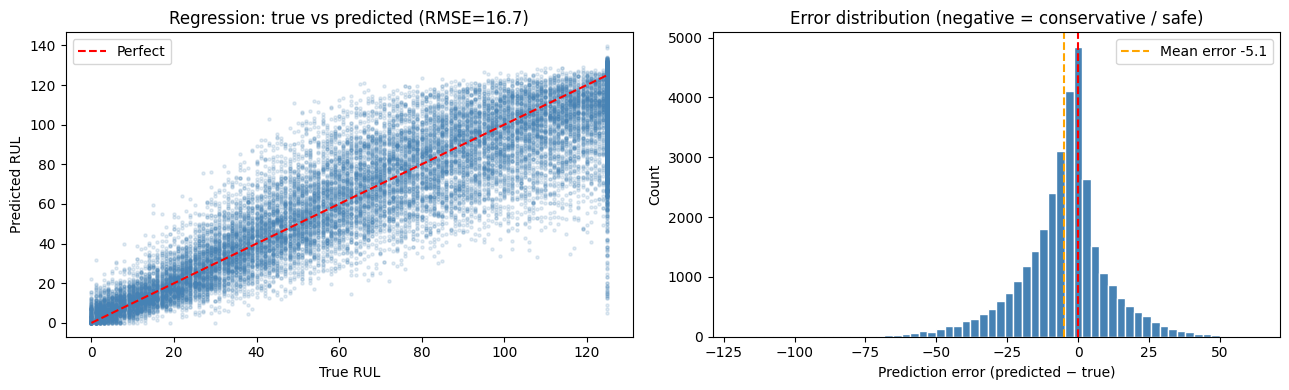

Mean error: -5.11  (negative = tends to under-predict RUL = conservative = good)


In [19]:
y_pred_reg = reg.predict(test_df[FEATURE_COLS]).clip(0)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"Internal test RMSE: {rmse:.2f} cycles")

# Visualise predicted vs true RUL
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], 'r--', lw=1.5, label='Perfect')
axes[0].set(xlabel='True RUL', ylabel='Predicted RUL',
            title=f'Regression: true vs predicted (RMSE={rmse:.1f})')
axes[0].legend()

err = y_pred_reg - y_test_reg
axes[1].hist(err, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].axvline(err.mean(), color='orange', ls='--', lw=1.5, label=f'Mean error {err.mean():.1f}')
axes[1].set(xlabel='Prediction error (predicted − true)', ylabel='Count',
            title='Error distribution (negative = conservative / safe)')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"Mean error: {err.mean():.2f}  (negative = tends to under-predict RUL = conservative = good)")

In [20]:
# Convert regression output to maintenance decisions: predicted_RUL < W → urgent
def reg_predict_fn(X):
    return (reg.predict(X).clip(0) < W).astype(int)

print(f"=== Regression — NASA hold-out maintenance evaluation (W={W}) ===")
print(f"    Trigger: predicted RUL < {W}  |  LEAD_TIME = {LEAD_TIME} cycles\n")

r_reg = evaluate_on_nasa(
    predict_fn=reg_predict_fn,
    nasa_df=nasa_raw, feature_cols=FEATURE_COLS,
)

print(f"  Urgent engines (true RUL < {W}): {r_reg['n_urgent']}")
print()
print(f"  Outcome for urgent engines:")
print(f"    Caught with ≥{LEAD_TIME} cycles lead time : {r_reg['caught_honest']:>3}  ({r_reg['recall_honest']:.1%})  ← honest recall")
print(f"    Caught but too late (< {LEAD_TIME} cycles) : {r_reg['caught_late']:>3}  ({r_reg['caught_late']/r_reg['n_urgent']:.1%})  ← alarm fired, not enough time")
print(f"    Never flagged — breakdown undetected : {r_reg['never_caught']:>3}  ({r_reg['never_caught']/r_reg['n_urgent']:.1%})  ← most dangerous")
print()
print(f"  Lenient recall (ever fired): {r_reg['caught_lenient']}/{r_reg['n_urgent']} = {r_reg['recall_lenient']:.1%}")
print(f"  False alarm rate: {r_reg['false_alarm']:.1%}")

=== Regression — NASA hold-out maintenance evaluation (W=30) ===
    Trigger: predicted RUL < 30  |  LEAD_TIME = 30 cycles

  Urgent engines (true RUL < 30): 157

  Outcome for urgent engines:
    Caught with ≥30 cycles lead time : 113  (72.0%)  ← honest recall
    Caught but too late (< 30 cycles) :  41  (26.1%)  ← alarm fired, not enough time
    Never flagged — breakdown undetected :   3  (1.9%)  ← most dangerous

  Lenient recall (ever fired): 154/157 = 98.1%
  False alarm rate: 6.9%


                                         Classifier      Regression
───────────────────────────────────────────────────────────────────
Urgent engines                                  157             157
Honest recall (≥W cycles lead time)          79.6%          72.0%
  ↳ caught with enough lead time                125             113
  ↳ caught late (alarm, no time)                 30              41
  ↳ never caught (breakdown risk)                 2               3
Lenient recall (ever fired)                  98.7%          98.1%
False alarm rate                             11.6%           6.9%


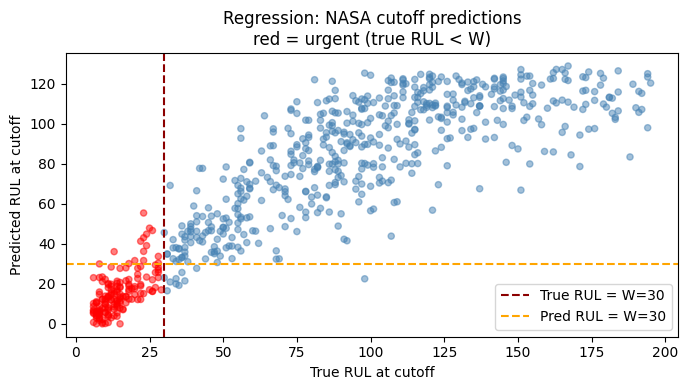

In [21]:

# Side-by-side comparison of both models
r_clf = evaluate_on_nasa(lambda X: clf.predict(X), nasa_raw, FEATURE_COLS)

print(f"{'':35} {'Classifier':>15} {'Regression':>15}")
print("─" * 67)
print(f"{'Urgent engines':35} {r_clf['n_urgent']:>15} {r_reg['n_urgent']:>15}")
print(f"{'Honest recall (≥W cycles lead time)':35} {r_clf['recall_honest']:>14.1%} {r_reg['recall_honest']:>14.1%}")
print(f"{'  ↳ caught with enough lead time':35} {r_clf['caught_honest']:>15} {r_reg['caught_honest']:>15}")
print(f"{'  ↳ caught late (alarm, no time)':35} {r_clf['caught_late']:>15} {r_reg['caught_late']:>15}")
print(f"{'  ↳ never caught (breakdown risk)':35} {r_clf['never_caught']:>15} {r_reg['never_caught']:>15}")
print(f"{'Lenient recall (ever fired)':35} {r_clf['recall_lenient']:>14.1%} {r_reg['recall_lenient']:>14.1%}")
print(f"{'False alarm rate':35} {r_clf['false_alarm']:>14.1%} {r_reg['false_alarm']:>14.1%}")

# Regression: scatter of predicted vs true RUL at cutoff
nasa_pred_rul = reg.predict(nasa_raw.sort_values('Time (Cycles)')
                               .groupby('Unit Number').last()[FEATURE_COLS]).clip(0)
nasa_true_rul = nasa_raw.groupby('Unit Number')['true_rul'].first().values

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(nasa_true_rul, nasa_pred_rul, alpha=0.5, s=20,
           c=['red' if t < W else 'steelblue' for t in nasa_true_rul])
ax.axvline(W, color='darkred', ls='--', lw=1.5, label=f'True RUL = W={W}')
ax.axhline(W, color='orange',  ls='--', lw=1.5, label=f'Pred RUL = W={W}')
ax.set(xlabel='True RUL at cutoff', ylabel='Predicted RUL at cutoff',
       title='Regression: NASA cutoff predictions\nred = urgent (true RUL < W)')
ax.legend(); plt.tight_layout(); plt.show()

Varying regression trigger threshold (urgency W fixed at 30)...
  T= 10: honest=1.9%  false_alarm=0.9%  late= 79  never=75
  T= 15: honest=9.6%  false_alarm=1.6%  late=100  never=42
  T= 20: honest=28.7%  false_alarm=3.1%  late= 91  never=21
  T= 25: honest=49.0%  false_alarm=4.9%  late= 70  never=10
  T= 30: honest=72.0%  false_alarm=6.9%  late= 41  never= 3
  T= 35: honest=81.5%  false_alarm=11.6%  late= 28  never= 1
  T= 40: honest=85.4%  false_alarm=16.2%  late= 22  never= 1
  T= 50: honest=94.3%  false_alarm=24.0%  late=  9  never= 0
  T= 60: honest=98.7%  false_alarm=30.0%  late=  2  never= 0
  T= 75: honest=100.0%  false_alarm=44.2%  late=  0  never= 0


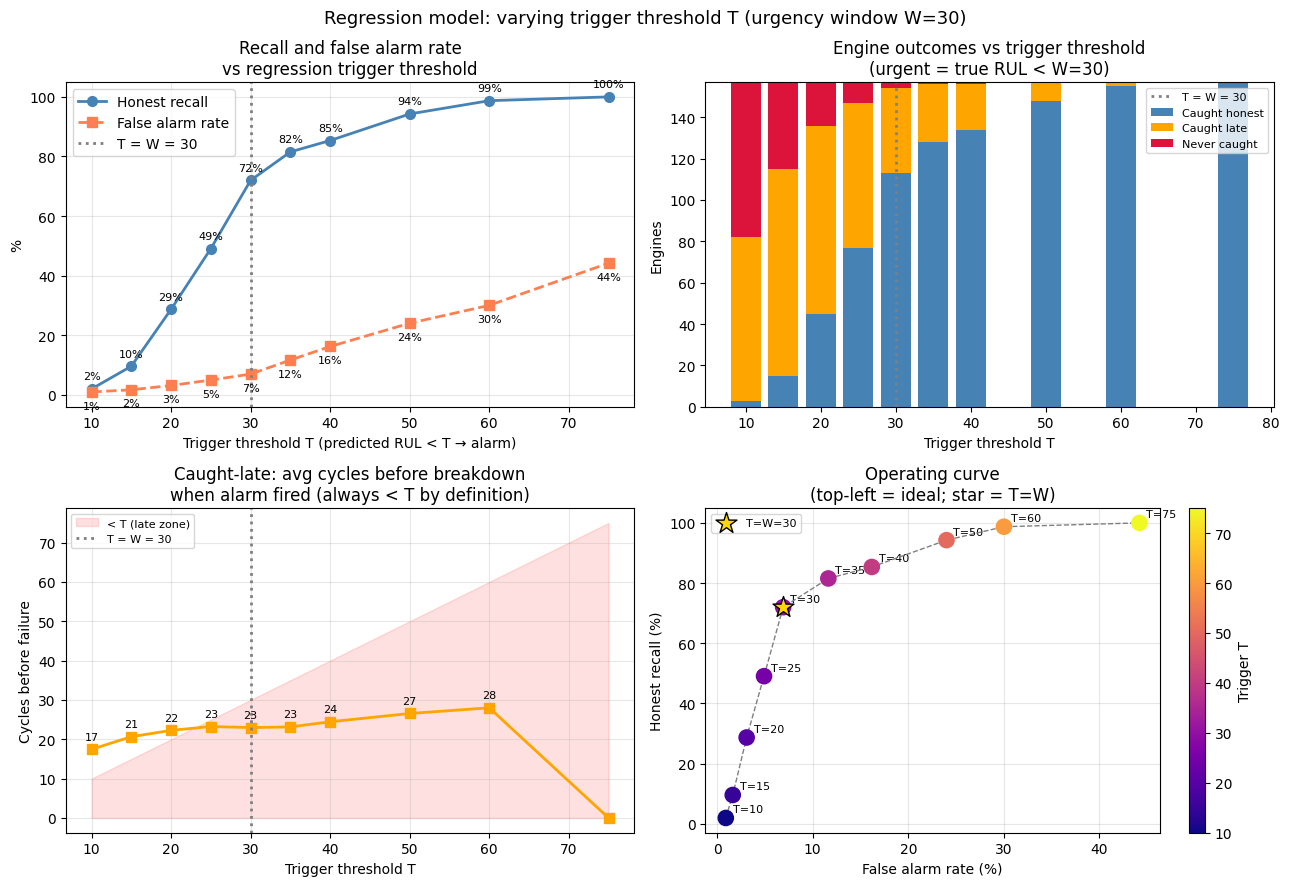

In [22]:
# Vary the regression trigger threshold independently of W
# W=30 stays fixed (defines which engines are "urgent")
# T = threshold at which predicted RUL triggers an alarm
print(f"Varying regression trigger threshold (urgency W fixed at {W})...")
triggers = [10, 15, 20, 25, 30, 35, 40, 50, 60, 75]
rc_rec   = []; rc_fa  = []; rc_ch  = []
rc_cl    = []; rc_nc  = []; rc_lcbf = []

for t in triggers:
    def pred_fn(X, t=t):
        return (reg.predict(X).clip(0) < t).astype(int)
    r = evaluate_on_nasa(pred_fn, nasa_raw, FEATURE_COLS, w=W, lead_time=W)
    rc_rec.append(r['recall_honest'] * 100)
    rc_fa.append(r['false_alarm'] * 100)
    rc_ch.append(r['caught_honest'])
    rc_cl.append(r['caught_late'])
    rc_nc.append(r['never_caught'])
    rc_lcbf.append(r['late_cbf'].mean() if len(r['late_cbf']) > 0 else 0)
    print(f"  T={t:>3}: honest={r['recall_honest']:.1%}  false_alarm={r['false_alarm']:.1%}"
          f"  late={r['caught_late']:>3}  never={r['never_caught']:>2}")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'Regression model: varying trigger threshold T (urgency window W={W})', fontsize=13)

# 1. Recall and false alarm vs trigger
ax = axes[0, 0]
ax.plot(triggers, rc_rec, 'o-', color='steelblue', lw=2, ms=7, label='Honest recall')
ax.plot(triggers, rc_fa,  's--', color='coral',    lw=2, ms=7, label='False alarm rate')
ax.axvline(W, color='gray', ls=':', lw=2, label=f'T = W = {W}')
for x, y in zip(triggers, rc_rec): ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points', xytext=(0, 7),  ha='center', fontsize=8)
for x, y in zip(triggers, rc_fa):  ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points', xytext=(0, -12), ha='center', fontsize=8)
ax.set(xlabel='Trigger threshold T (predicted RUL < T → alarm)', ylabel='%',
       title='Recall and false alarm rate\nvs regression trigger threshold')
ax.legend(); ax.grid(True, alpha=0.3)

# 2. Engine outcome breakdown vs trigger
ax = axes[0, 1]
bot = np.array(rc_ch)
bot2 = bot + np.array(rc_cl)
w_arr = np.array(triggers)
ax.bar(w_arr, rc_ch, color='steelblue', width=4, label='Caught honest')
ax.bar(w_arr, rc_cl, color='orange',    width=4, bottom=rc_ch,         label='Caught late')
ax.bar(w_arr, rc_nc, color='crimson',   width=4, bottom=list(bot2),    label='Never caught')
ax.axvline(W, color='gray', ls=':', lw=2, label=f'T = W = {W}')
ax.set(xlabel='Trigger threshold T', ylabel='Engines',
       title=f'Engine outcomes vs trigger threshold\n(urgent = true RUL < W={W})')
ax.legend(fontsize=8)

# 3. Caught-late avg cycles before failure vs trigger
ax = axes[1, 0]
ax.fill_between(triggers, 0, triggers, alpha=0.12, color='red', label='< T (late zone)')
ax.plot(triggers, rc_lcbf, 's-', color='orange', lw=2, ms=7)
for x, y in zip(triggers, rc_lcbf):
    if y > 0: ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 7), ha='center', fontsize=8)
ax.axvline(W, color='gray', ls=':', lw=2, label=f'T = W = {W}')
ax.set(xlabel='Trigger threshold T', ylabel='Cycles before failure',
       title='Caught-late: avg cycles before breakdown\nwhen alarm fired (always < T by definition)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# 4. Operating curve (parameterised by trigger)
ax = axes[1, 1]
sc = ax.scatter(rc_fa, rc_rec, c=triggers, cmap='plasma', s=120, zorder=5)
ax.plot(rc_fa, rc_rec, '--', color='gray', lw=1, zorder=4)
for x, y, t in zip(rc_fa, rc_rec, triggers):
    ax.annotate(f'T={t}', (x, y), textcoords='offset points', xytext=(5, 4), fontsize=8)
# Mark T=W
idx_w = triggers.index(W) if W in triggers else None
if idx_w is not None:
    ax.scatter([rc_fa[idx_w]], [rc_rec[idx_w]], s=250, marker='*',
               color='gold', edgecolors='black', zorder=6, label=f'T=W={W}')
plt.colorbar(sc, ax=ax, label='Trigger T')
ax.set(xlabel='False alarm rate (%)', ylabel='Honest recall (%)',
       title='Operating curve\n(top-left = ideal; star = T=W)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Final maintenance schedule: one row per NASA engine
# Use classifier for the binary decision; regression for the RUL estimate
nasa_last = (
    nasa_raw.sort_values('Time (Cycles)')
    .groupby('Unit Number').last()
    .reset_index()
)

nasa_last['clf_pred']  = clf.predict(nasa_last[FEATURE_COLS])
nasa_last['clf_prob']  = clf.predict_proba(nasa_last[FEATURE_COLS])[:, 1]
nasa_last['pred_rul']  = reg.predict(nasa_last[FEATURE_COLS]).clip(0).round(1)

schedule = nasa_last[['Unit Number', 'dataset', 'Time (Cycles)',
                       'true_rul', 'clf_pred', 'clf_prob', 'pred_rul']].copy()
schedule.columns = ['Engine', 'Dataset', 'Last cycle', 'True RUL',
                    'Urgent (clf)', 'Urgency prob', 'Predicted RUL (reg)']
schedule['Status'] = schedule['Urgent (clf)'].map({1: 'SCHEDULE MAINTENANCE', 0: 'Safe'})
schedule['Correct'] = ((schedule['True RUL'] < W) == schedule['Urgent (clf)'].astype(bool))

print(f"Maintenance schedule summary (W={W}):")
print(f"  Total engines        : {len(schedule)}")
print(f"  Scheduled (clf=1)    : {schedule['Urgent (clf)'].sum()}")
print(f"  Correct decisions    : {schedule['Correct'].sum()} / {len(schedule)}")
tp = ((schedule['True RUL'] < W) & schedule['Urgent (clf)'].astype(bool)).sum()
fn = ((schedule['True RUL'] < W) & ~schedule['Urgent (clf)'].astype(bool)).sum()
print(f"  True positives       : {tp}  (urgent engines correctly flagged)")
print(f"  False negatives      : {fn}  (urgent engines missed — dangerous)")
print()
print("Engines flagged for maintenance (sorted by urgency probability):")
flagged = schedule[schedule['Urgent (clf)'] == 1].sort_values('Urgency prob', ascending=False)
print(flagged.head(15)[['Engine','Dataset','Last cycle','True RUL',
                         'Urgency prob','Predicted RUL (reg)','Status']].to_string(index=False))

Maintenance schedule summary (W=30):
  Total engines        : 707
  Scheduled (clf=1)    : 188
  Correct decisions    : 666 / 707
  True positives       : 152  (urgent engines correctly flagged)
  False negatives      : 5  (urgent engines missed — dangerous)

Engines flagged for maintenance (sorted by urgency probability):
 Engine Dataset  Last cycle  True RUL  Urgency prob  Predicted RUL (reg)               Status
     82   FD001         162         9      0.999713                  2.1 SCHEDULE MAINTENANCE
     34   FD001         203         7      0.999680                  0.0 SCHEDULE MAINTENANCE
    385   FD003         130        11      0.999581                  6.9 SCHEDULE MAINTENANCE
    405   FD003         180         7      0.999440                  5.1 SCHEDULE MAINTENANCE
    453   FD003         333        10      0.999385                  5.8 SCHEDULE MAINTENANCE
    441   FD003         194         6      0.999342                  5.6 SCHEDULE MAINTENANCE
    458   FD003  